**Section 1 — Install Packages**

In [ ]:
#!pip install -q -U transformers accelerate datasets evaluate scikit-learn matplotlib pandas
#!pip install -q -U torchvision

In [1]:
#Verifying the packages

import torch
import accelerate
import transformers

print(f"PyTorch: {torch.__version__}")
print(f"Accelerate: {accelerate.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")

PyTorch: 2.12.1+cu130
Accelerate: 1.14.0
Transformers: 5.12.1
GPU Available: True


**Section 2 — Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

import torch

from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
)

**Section 3 — Load IMDb Dataset**

In [2]:
dataset = load_dataset("stanfordnlp/imdb")

train = dataset["train"]
test = dataset["test"]

print(train)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 25000
})


**Section 4 — Exploratory Data Analysis**

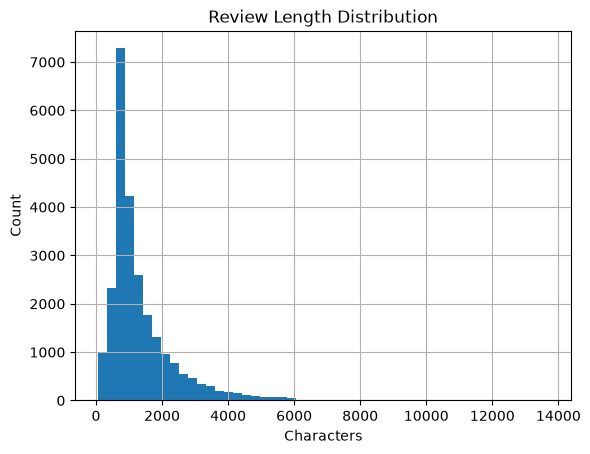

label
0    12500
1    12500
Name: count, dtype: int64

In [3]:
# It Displays: Number of reviews, Positive vs Negative, Review length histogram and class balance

train_df = pd.DataFrame(train)

train_df["review_length"] = train_df["text"].apply(len)

train_df["review_length"].hist(bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.show()
train_df["label"].value_counts()

**Section 5 — Baseline Model**

In [4]:
#TF-IDF

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train = vectorizer.fit_transform(train_df["text"])

X_test = vectorizer.transform(
    pd.DataFrame(test)["text"]
)

In [5]:
#Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(
    X_train,
    train_df["label"]
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [6]:
#Prediction

baseline_preds = lr.predict(X_test)

In [7]:
#Metrics

accuracy = accuracy_score(test["label"], baseline_preds)
precision = precision_score(test["label"], baseline_preds)
recall = recall_score(test["label"], baseline_preds)
f1 = f1_score(test["label"], baseline_preds)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.88036
Precision: 0.879297965696051
Recall   : 0.88176
F1 Score : 0.8805272618334332


In [8]:
#Classification Report

print(
    classification_report(
        test["label"],
        baseline_preds
    )
)

              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



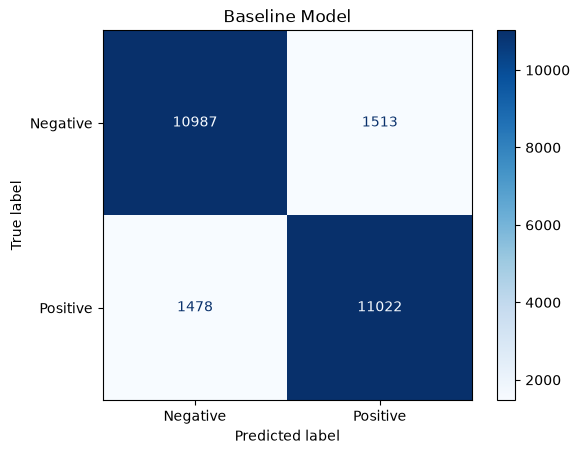

In [9]:
#Confusion Matrix

cm = confusion_matrix(
    test["label"],
    baseline_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Blues")

plt.title("Baseline Model")
plt.show()

**Section 6 — Fine-tune DistilBERT**

In [10]:
#Tokenizer

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [11]:
#Tokenization

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256,
    )

tokenized = dataset.map(tokenize, batched=True)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [12]:
#Remove "text" column

tokenized = tokenized.rename_column("label", "labels")
tokenized = tokenized.remove_columns(["text"])
tokenized.set_format("torch")

In [13]:
#Load model

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2,
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [14]:
#Metrics Function

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, average='binary'),
        "recall": recall_score(labels, predictions, average='binary'),
        "f1": f1_score(labels, predictions, average='binary'),
    }


In [15]:
#Training

training_args = TrainingArguments(

    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    fp16=True,
)

In [16]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    compute_metrics=compute_metrics,
)
print("Trainer initialized successfully.")

Trainer initialized successfully.


In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.255730,0.261340,0.895600,0.947754,0.837360,0.889144
2,0.143268,0.271280,0.913920,0.909141,0.919760,0.914420


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3126, training_loss=0.22933041950257557, metrics={'train_runtime': 427.9625, 'train_samples_per_second': 116.833, 'train_steps_per_second': 7.304, 'total_flos': 3311684966400000.0, 'train_loss': 0.22933041950257557, 'epoch': 2.0})

**Section 7 — Evaluate DistilBERT**

In [18]:
results = trainer.evaluate()
print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.143268,0.261340,2,0.895600,0.947754,0.837360,0.889144


{'eval_loss': 0.26133978366851807, 'eval_accuracy': 0.8956, 'eval_precision': 0.9477544367982615, 'eval_recall': 0.83736, 'eval_f1': 0.8891437308868502}


In [19]:
#Training

predictions = trainer.predict(tokenized["test"])

bert_preds = np.argmax(
    predictions.predictions,
    axis=1
)

In [20]:
#Classification Report

print(
    classification_report(
        test["label"],
        bert_preds
    )
)

              precision    recall  f1-score   support

           0       0.85      0.95      0.90     12500
           1       0.95      0.84      0.89     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



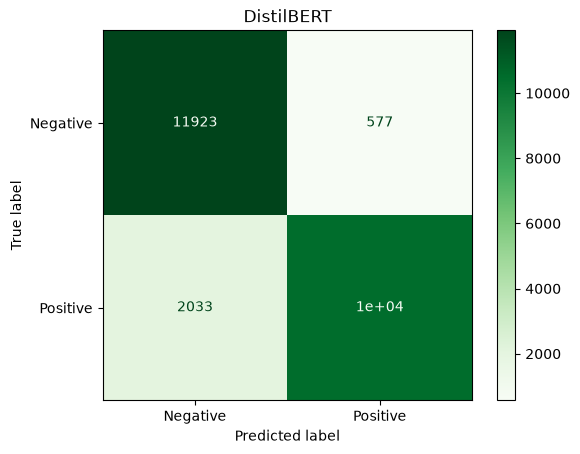

In [21]:
#Confusion Matrix

cm = confusion_matrix(
    test["label"],
    bert_preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative","Positive"]
)

disp.plot(cmap="Greens")

plt.title("DistilBERT")
plt.show()

**Section 8 — Model Comparison**

In [23]:
comparison = pd.DataFrame({
    "Model":[
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy":[
        accuracy,
        results["eval_accuracy"]
    ],
    "Precision":[
        precision,
        results["eval_precision"]
    ],
    "Recall":[
        recall,
        results["eval_recall"]
    ],
    "F1":[
        f1,
        results["eval_f1"]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression,0.88036,0.879298,0.88176,0.880527
1,DistilBERT,0.89560,0.947754,0.83736,0.889144


**Section 9 — Custom Prediction and Saving the model**

In [24]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer
)

classifier(
    "This movie was absolutely amazing!"
)

[{'label': 'LABEL_1', 'score': 0.9906237721443176}]

In [25]:
# Save the model and tokenizer for future use
model_path = "./sentiment_model"

trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

print(f"Model and tokenizer saved to {model_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to ./sentiment_model
